In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
import torchvision
import torchvision.transforms as transforms

In [ ]:
transform =  transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
print(train_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomCrop(size=(224, 224), padding=4)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(
    root = "./data",
    train= True,
    download = True,
    transform = train_transform
)

test_dataset= torchvision.datasets.CIFAR10(
    root = "./data",
    train = False,
    download = True,
    transform = test_transform
)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


In [ ]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 50000
Test dataset size: 10000


In [ ]:
train_dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))
print(f"images shape: {images.shape}")
print(f"labels shape: {labels.shape}")

images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])


now let's build ***VGG-16*** manually

#VGG16

In [ ]:
from dataclasses import dataclass

@dataclass
class CFG:
    IMG_SIZE: int = 224
    IN_CHANNELS: int = 3
    NUM_CLASSES: int = 10
    DROPOUT: float = 0.5

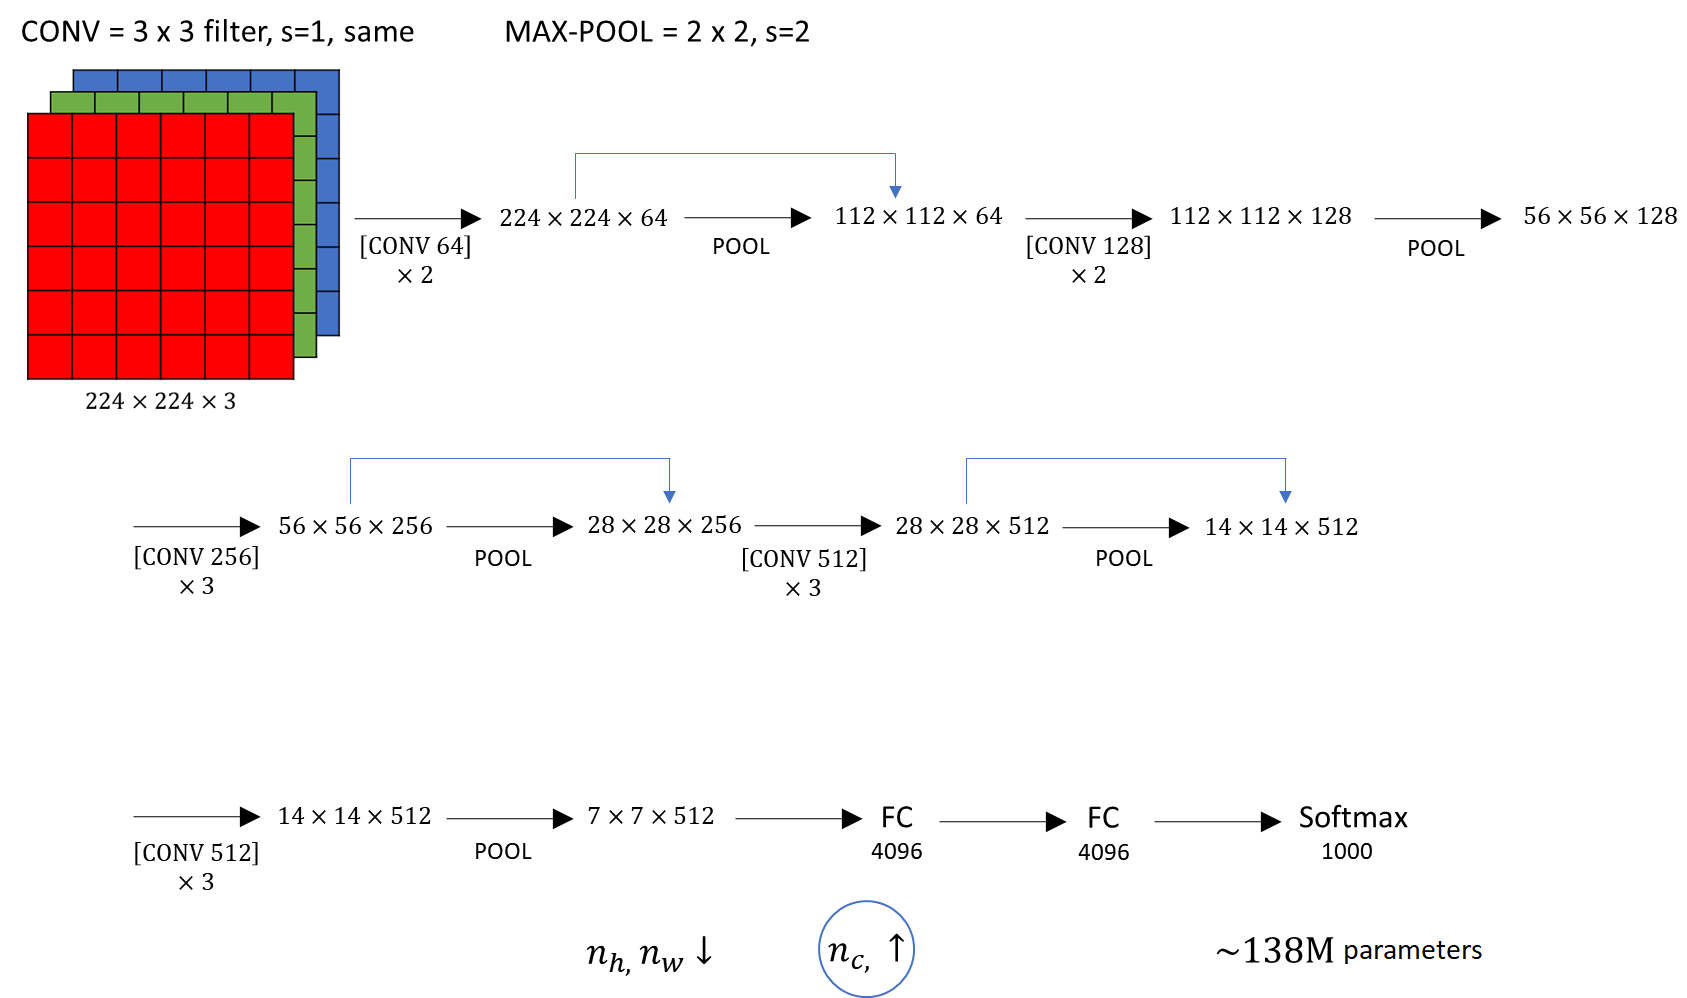

In [ ]:
class VGG16(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(cfg.IN_CHANNELS, 64, kernel_size=3, stride=1, padding=1)
        self.relu1_1 = nn.ReLU(inplace=True)

        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.relu1_2 = nn.ReLU(inplace=True)

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.relu2_1 = nn.ReLU(inplace=True)

        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.relu2_2 = nn.ReLU(inplace=True)

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.relu3_1 = nn.ReLU(inplace=True)

        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.relu3_2 = nn.ReLU(inplace=True)

        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.relu3_3 = nn.ReLU(inplace=True)

        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)


        # Block 4
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.relu4_1 = nn.ReLU(inplace=True)

        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.relu4_2 = nn.ReLU(inplace=True)

        self.conv4_3 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.relu4_3 = nn.ReLU(inplace=True)

        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 5
        self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.relu5_1 = nn.ReLU(inplace=True)

        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.relu5_2 = nn.ReLU(inplace=True)

        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.relu5_3 = nn.ReLU(inplace=True)

        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Classifier
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(512 * 7 * 7, 4096)
        self.relu_fc1 = nn.ReLU(inplace=True)
        self.drop1 = nn.Dropout(cfg.DROPOUT)

        self.fc2 = nn.Linear(4096, 4096)
        self.relu_fc2 = nn.ReLU(inplace=True)
        self.drop2 = nn.Dropout(cfg.DROPOUT)

        self.fc3 = nn.Linear(4096, cfg.NUM_CLASSES)

    def forward(self, x):
        # Block 1
        x = self.conv1_1(x)
        x = self.relu1_1(x)

        x = self.conv1_2(x)
        x = self.relu1_2(x)

        x = self.pool1(x)

        # Block 2
        x = self.conv2_1(x)
        x = self.relu2_1(x)

        x = self.conv2_2(x)
        x = self.relu2_2(x)

        x = self.pool2(x)

        # Block 3
        x = self.conv3_1(x)
        x = self.relu3_1(x)

        x = self.conv3_2(x)
        x = self.relu3_2(x)

        x = self.conv3_3(x)
        x = self.relu3_3(x)

        x = self.pool3(x)

        # Block 4
        x = self.conv4_1(x)
        x = self.relu4_1(x)

        x = self.conv4_2(x)
        x = self.relu4_2(x)

        x = self.conv4_3(x)
        x = self.relu4_3(x)

        x = self.pool4(x)

        # Block 5
        x = self.conv5_1(x)
        x = self.relu5_1(x)

        x = self.conv5_2(x)
        x = self.relu5_2(x)

        x = self.conv5_3(x)
        x = self.relu5_3(x)

        x = self.pool5(x)

        # Classifier
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu_fc1(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.relu_fc2(x)
        x = self.drop2(x)

        x = self.fc3(x)

        return x

In [ ]:
cfg = CFG()
model = VGG16(cfg).to(device)
print(model)

VGG16(
  (conv1_1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1_1): ReLU(inplace=True)
  (conv1_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1_2): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2_1): ReLU(inplace=True)
  (conv2_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2_2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3_1): ReLU(inplace=True)
  (conv3_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3_2): ReLU(inplace=True)
  (conv3_3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3_3): ReLU(inplace=True)
  (pool3): MaxPool2d(kernel_size=2, 

In [ ]:
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 10])


In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)   # [B, 3, 224, 224]
print(labels.shape)   # [B]

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
images.shape

torch.Size([32, 3, 224, 224])

In [ ]:
images[0].unsqueeze(0).shape

torch.Size([1, 3, 224, 224])

In [ ]:
image = images[0].unsqueeze(0).to(device)
label = labels[0]

print("Image shape:", image.shape)
print("Label:", label.item())
print("Class name:", train_dataset.classes[label.item()])

Image shape: torch.Size([1, 3, 224, 224])
Label: 2
Class name: bird


In [ ]:
model.eval()

with torch.no_grad():
    feat1 = model.conv1_1(image)   # [1, 64, 224, 224]
    feat1 = model.relu1_1(feat1)

print("Feature map shape:", feat1.shape)

Feature map shape: torch.Size([1, 64, 224, 224])


In [ ]:
feature_maps = feat1.squeeze(0).cpu()   # [64, 224, 224]
print(feature_maps.shape)

torch.Size([64, 224, 224])


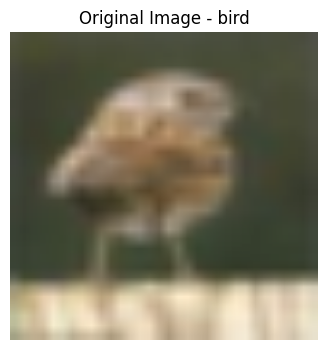

In [ ]:
import matplotlib.pyplot as plt
def denormalize(img):
    img = img.clone().cpu()
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)

img_show = denormalize(image.squeeze(0))
img_show = img_show.permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_show)
plt.title(f"Original Image - {train_dataset.classes[label.item()]}")
plt.axis("off")
plt.show()

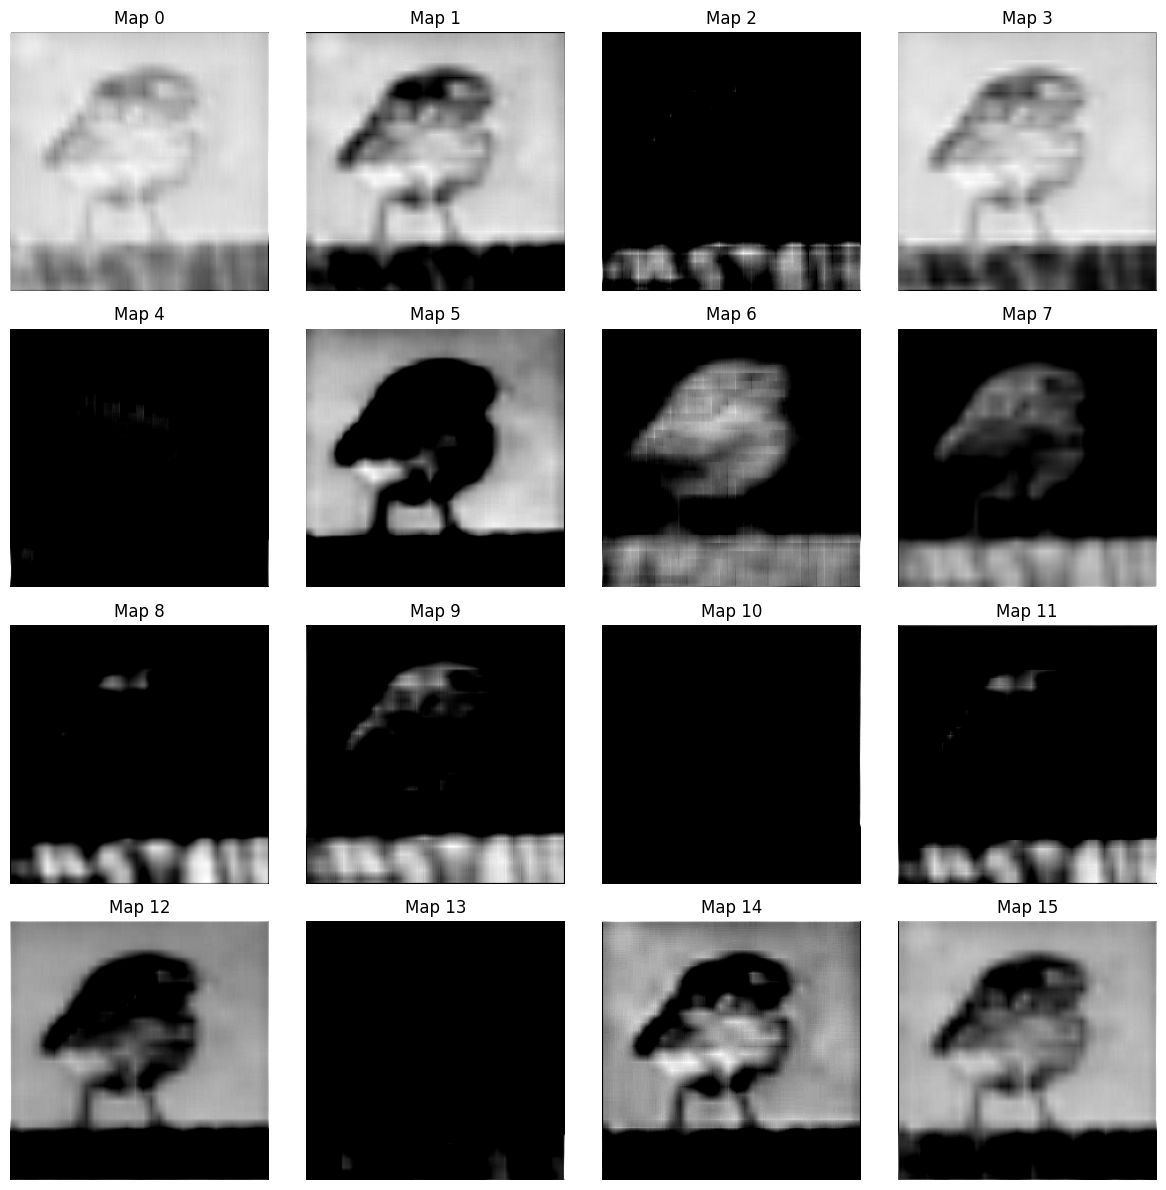

In [ ]:
#first 16 feature map
num_maps = 16

plt.figure(figsize=(12, 12))

for i in range(num_maps):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps[i], cmap="gray")
    plt.title(f"Map {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.eval()

images, labels = next(iter(train_loader))
image = images[0].unsqueeze(0).to(device)
label = labels[0]

print("Class:", train_dataset.classes[label.item()])


def denormalize(img):
    img = img.detach().cpu().clone()
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)

Class: cat


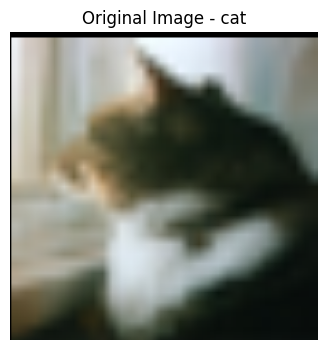

In [ ]:
img_show = denormalize(image.squeeze(0)).permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_show)
plt.title(f"Original Image - {train_dataset.classes[label.item()]}")
plt.axis("off")
plt.show()

#lvl 1 feature map

In [ ]:
with torch.no_grad():
    x1 = model.conv1_1(image)
    x1 = model.relu1_1(x1)

print("conv1_1 shape:", x1.shape)

conv1_1 shape: torch.Size([1, 64, 224, 224])


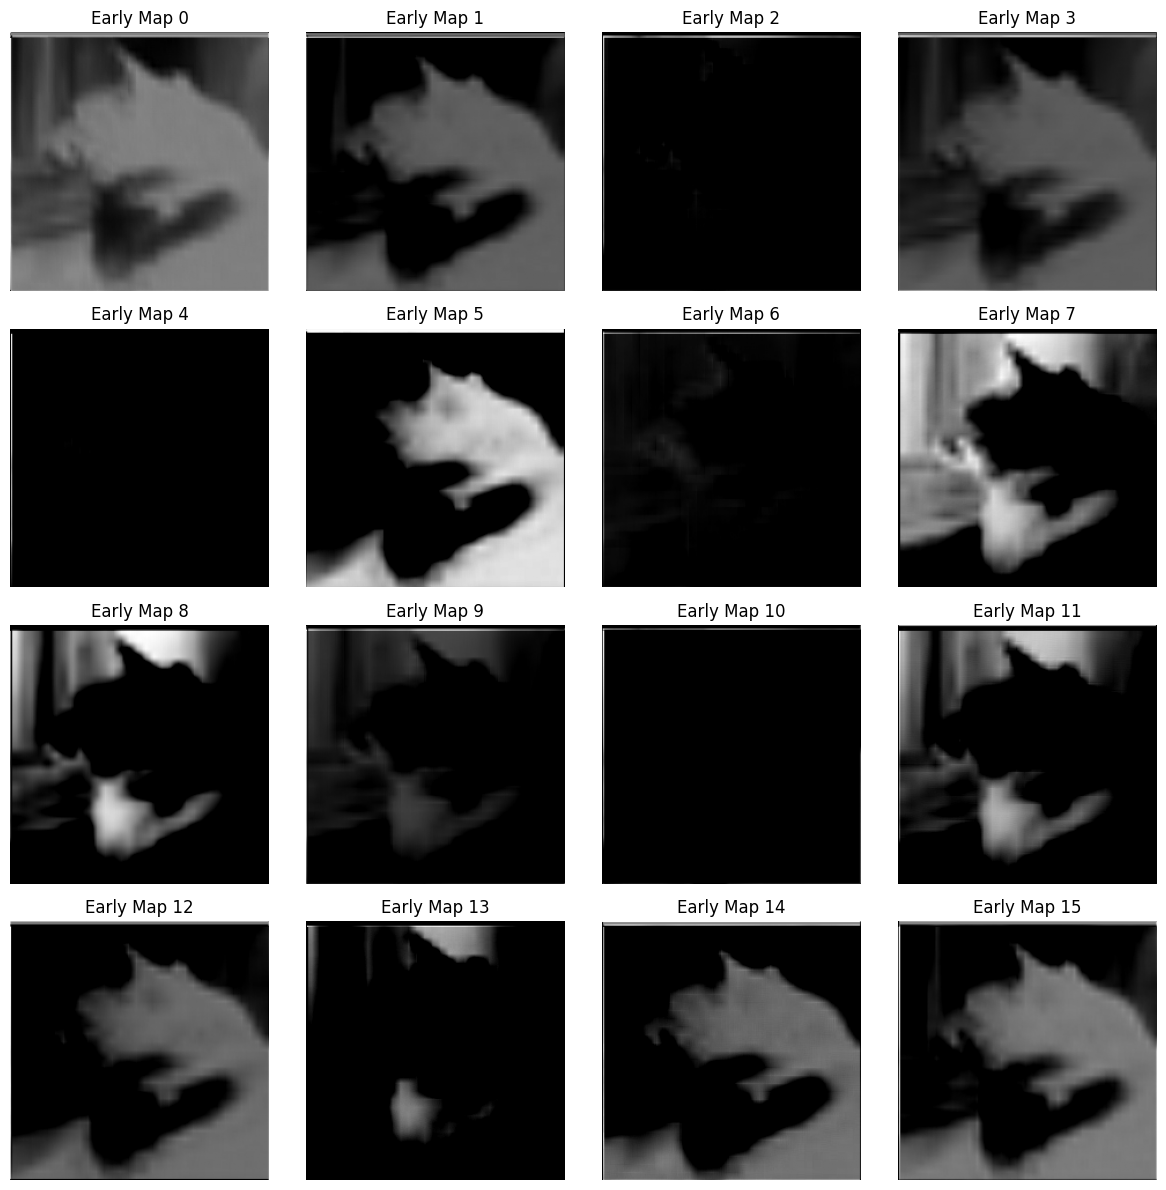

In [ ]:
feature_maps_1 = x1.squeeze(0).cpu()

num_maps = 16
plt.figure(figsize=(12, 12))

for i in range(num_maps):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps_1[i], cmap="gray")
    plt.title(f"Early Map {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#middle lvl feature map

In [ ]:
with torch.no_grad():
    x = model.conv1_1(image)
    x = model.relu1_1(x)
    x = model.conv1_2(x)
    x = model.relu1_2(x)
    x = model.pool1(x)

    x = model.conv2_1(x)
    x = model.relu2_1(x)
    x = model.conv2_2(x)
    x = model.relu2_2(x)
    x = model.pool2(x)

    x3 = model.conv3_1(x)
    x3 = model.relu3_1(x3)

print("conv3_1 shape:", x3.shape)

conv3_1 shape: torch.Size([1, 256, 56, 56])


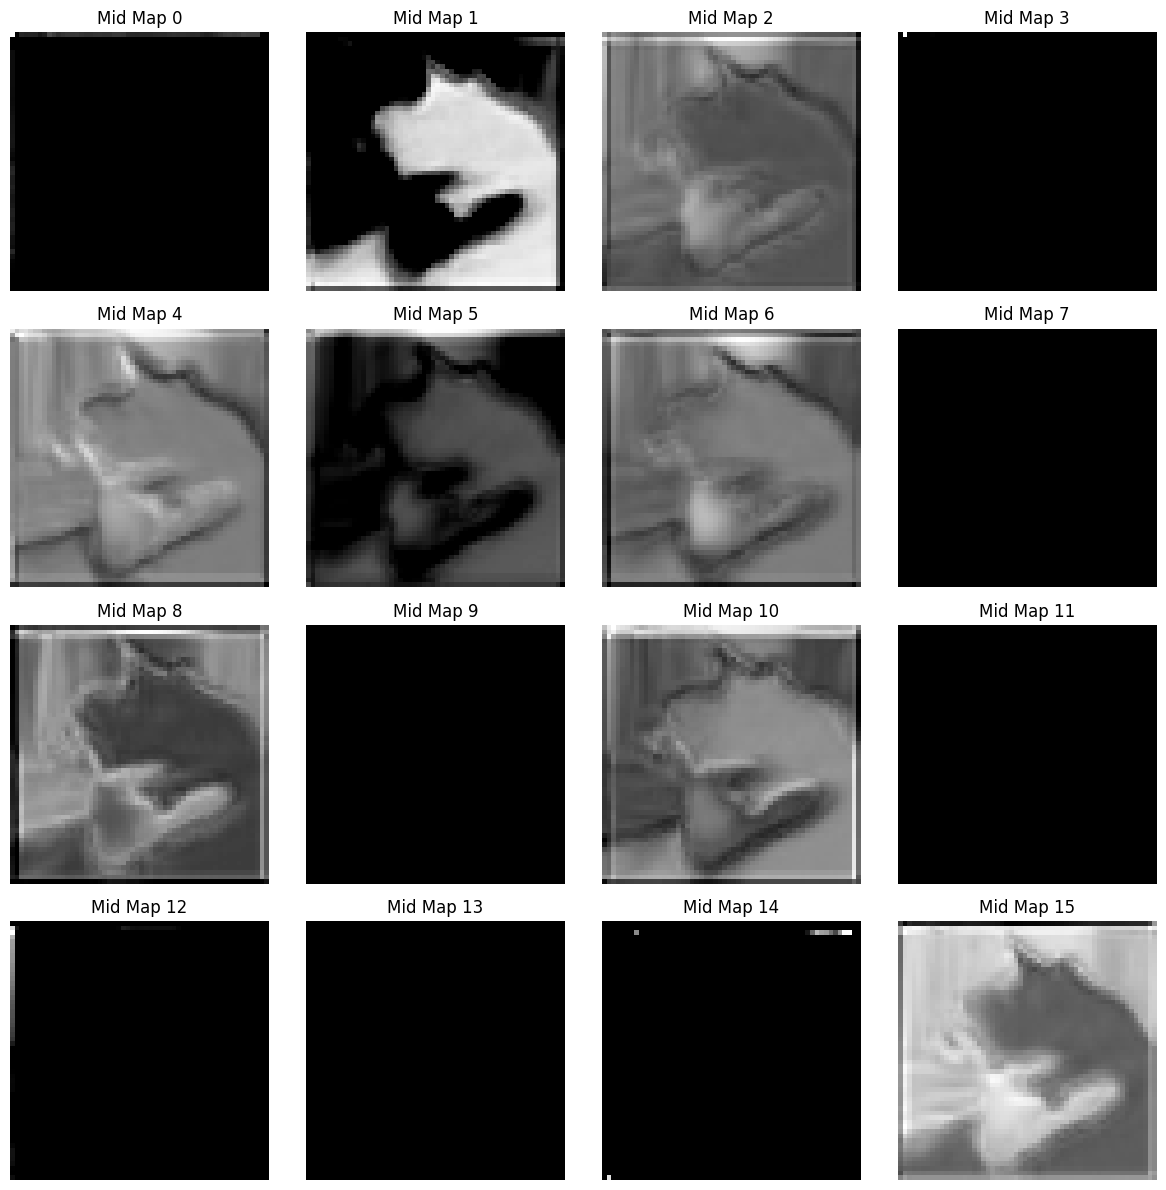

In [ ]:
feature_maps_3 = x3.squeeze(0).cpu()

num_maps = 16
plt.figure(figsize=(12, 12))

for i in range(num_maps):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps_3[i], cmap="gray")
    plt.title(f"Mid Map {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#deep level feature map

In [ ]:
with torch.no_grad():
    x = model.conv1_1(image)
    x = model.relu1_1(x)
    x = model.conv1_2(x)
    x = model.relu1_2(x)
    x = model.pool1(x)

    x = model.conv2_1(x)
    x = model.relu2_1(x)
    x = model.conv2_2(x)
    x = model.relu2_2(x)
    x = model.pool2(x)

    x = model.conv3_1(x)
    x = model.relu3_1(x)
    x = model.conv3_2(x)
    x = model.relu3_2(x)
    x = model.conv3_3(x)
    x = model.relu3_3(x)
    x = model.pool3(x)

    x = model.conv4_1(x)
    x = model.relu4_1(x)
    x = model.conv4_2(x)
    x = model.relu4_2(x)
    x = model.conv4_3(x)
    x = model.relu4_3(x)
    x = model.pool4(x)

    x5 = model.conv5_3(x)
    x5 = model.relu5_3(x5)

print("conv5_3 shape:", x5.shape)

conv5_3 shape: torch.Size([1, 512, 14, 14])


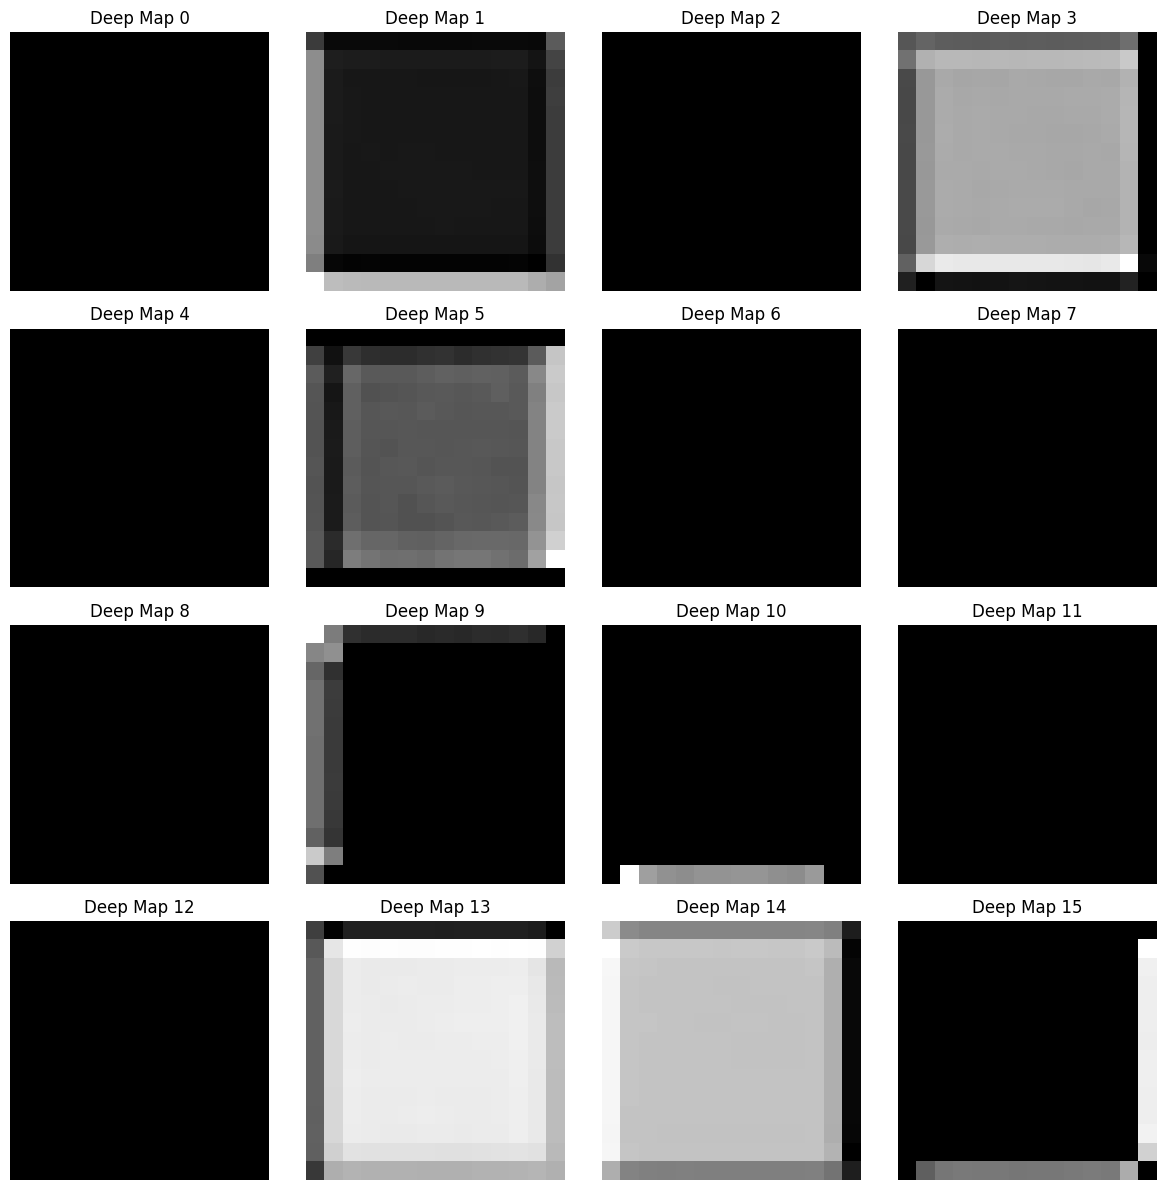

In [ ]:
feature_maps_5 = x5.squeeze(0).cpu()

num_maps = 16
plt.figure(figsize=(12, 12))

for i in range(num_maps):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps_5[i], cmap="gray")
    plt.title(f"Deep Map {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()